In [1]:
import numpy as np
from skimage.registration import phase_cross_correlation
import os
from matplotlib import pyplot as plt
import cv2
from skimage.transform import warp

In [ ]:
file_name = "merged_shifted_final"
# folder_name = "../results/40x_10mms_20line_fs/40x_10mms_20line_fs_layer_0/"
# result_dir = "../results/40x_10mms_20line_fs/40x_10mms_20line_fs_layer_0/image_registration/"
axis = "y" #or "x"
target_dir = "../results/paper_rgb/g/"
folder_name = "../results/paper_rgb/r/"
result_dir = "../results/paper_rgb/r/image_registration/"
os.makedirs(result_dir, exist_ok=True)

In [3]:
sparse_matrix_x = np.load(target_dir+file_name+'_x.npy').T
if axis == "x":
    sparse_matrix_y = np.load(folder_name+file_name+'_x.npy').T
else:
    sparse_matrix_y = np.load(folder_name+file_name+'_y.npy')
plt.imsave(os.path.join(result_dir, "test_shift_x_original.png"), sparse_matrix_x[::8, ::8], vmin=-1, vmax=1)
plt.imsave(os.path.join(result_dir, "test_shift_y_original.png"), sparse_matrix_y[::8, ::8], vmin=-1, vmax=1)
# sparse_matrix_x = np.roll(sparse_matrix_x, -800, axis=0)

In [4]:
# square_size = 15*2000
# sparse_matrix_x = sparse_matrix_x[sparse_matrix_x.shape[0]//2-square_size//2:sparse_matrix_x.shape[0]//2+square_size//2, sparse_matrix_x.shape[1]//2-square_size//2:sparse_matrix_x.shape[1]//2+square_size//2]
# sparse_matrix_y = sparse_matrix_y[sparse_matrix_y.shape[0]//2-square_size//2:sparse_matrix_y.shape[0]//2+square_size//2, sparse_matrix_y.shape[1]//2-square_size//2:sparse_matrix_y.shape[1]//2+square_size//2]

In [5]:
sparse_matrix_x = np.clip(sparse_matrix_x, -25, 25)
sparse_matrix_y = np.clip(sparse_matrix_y, -25, 25)
# sparse_matrix_x = np.where(np.abs(sparse_matrix_x) > 4, sparse_matrix_x, 0)
# sparse_matrix_y = np.where(np.abs(sparse_matrix_y) > 4, sparse_matrix_y, 0)
# sparse_matrix_x = np.clip(sparse_matrix_x, -4, 4)
# sparse_matrix_y = np.clip(sparse_matrix_y, -4, 4)
# sparse_matrix_x = np.where(np.abs(sparse_matrix_x) == 1, 2, sparse_matrix_x)
# sparse_matrix_y = np.where(np.abs(sparse_matrix_y) == 1, 2, sparse_matrix_y)

(4000, 4000) (4000, 4000)


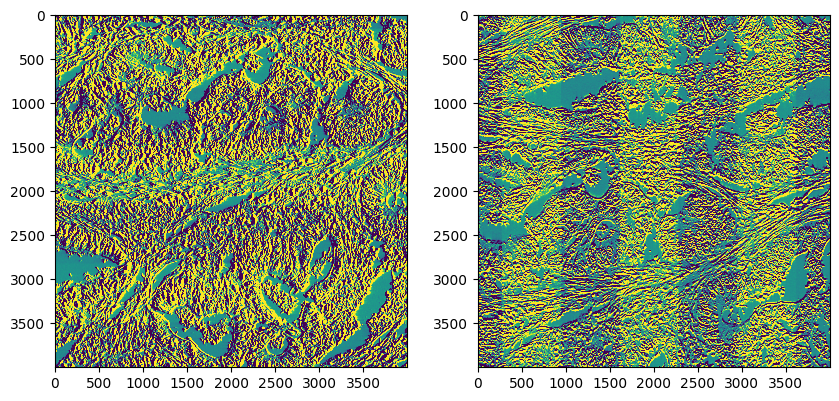

In [6]:
center_x, center_y = 3500, 3400
half_size = 2000
crop_box = (center_x-half_size, center_y-half_size, center_x+half_size, center_y+half_size)
# sparse_matrix_x_crop = sparse_matrix_x.toarray()[crop_box[0]:crop_box[2], crop_box[1]:crop_box[3]]
# sparse_matrix_y_crop = sparse_matrix_y.toarray()[crop_box[0]:crop_box[2], crop_box[1]:crop_box[3]]
sparse_matrix_x_crop = sparse_matrix_x[crop_box[0]:crop_box[2], crop_box[1]:crop_box[3]]
sparse_matrix_y_crop = sparse_matrix_y[crop_box[0]:crop_box[2], crop_box[1]:crop_box[3]]
print(sparse_matrix_x_crop.shape, sparse_matrix_y_crop.shape)
# plot the cropped matrices
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop, vmax=1, vmin=-1)
ax1.imshow(sparse_matrix_y_crop, vmax=1, vmin=-1)
plt.show()

[  0  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180 190
 200] [9865763 1362540 1079207  916273  822117  716076  556043  366834  195602
   80641   27456    7656    2385     816     278     192      86      22
      13]
[  0  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180 190
 200 210 220 230 240] [11603633  1257255   881255   651197   492758   378519   284570   205379
   130441    65610    28333    11769     5107     2311     1027      461
      213       76       32       23       16       10        5]


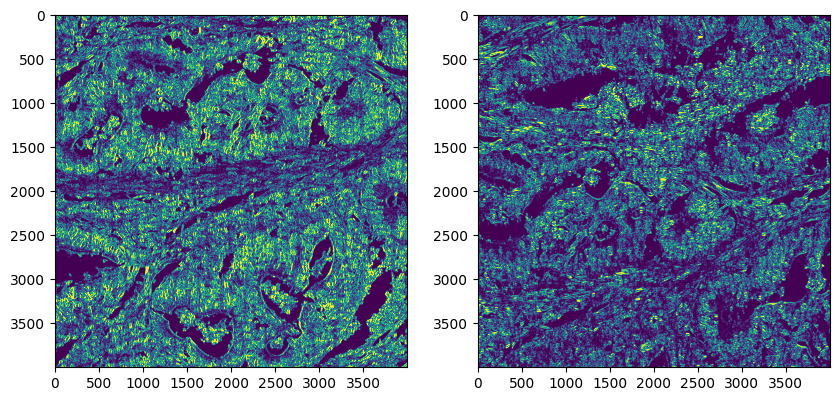

In [7]:
sparse_matrix_x_crop_abs = (np.abs(sparse_matrix_x_crop).astype(np.uint8)) * 10
sparse_matrix_y_crop_abs = (np.abs(sparse_matrix_y_crop).astype(np.uint8)) * 10
sparse_matrix_x_crop_abs = np.where(sparse_matrix_x_crop_abs < 30, 0, sparse_matrix_x_crop_abs)
sparse_matrix_y_crop_abs = np.where(sparse_matrix_y_crop_abs < 30, 0, sparse_matrix_y_crop_abs)
unique, counts = np.unique(sparse_matrix_x_crop_abs, return_counts=True)
print(unique, counts)
unique, counts = np.unique(sparse_matrix_y_crop_abs, return_counts=True)
print(unique, counts)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop_abs, vmin=0, vmax=62)
ax1.imshow(sparse_matrix_y_crop_abs, vmin=0, vmax=62)
plt.show()

[-1313.  1004.]


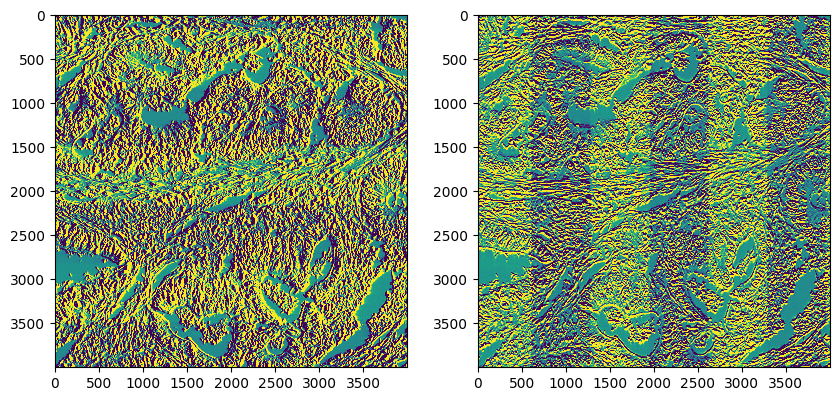

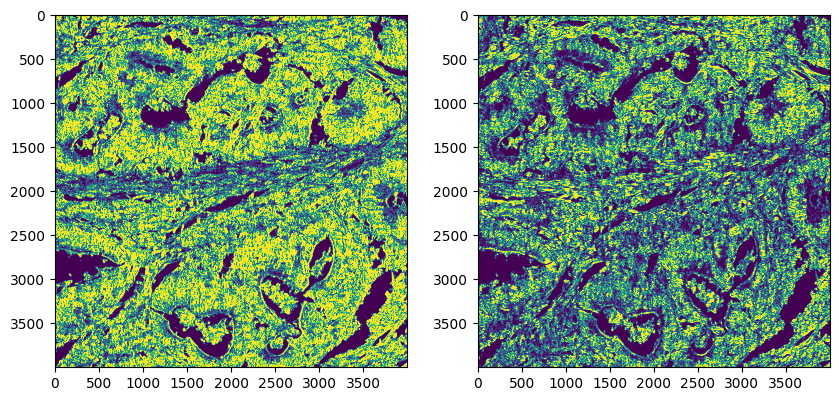

In [8]:
# mask_x = sparse_matrix_x_crop_abs != 0
# mask_y = sparse_matrix_y_crop_abs != 0
# shift, error, diffphase = phase_cross_correlation(sparse_matrix_x_crop, sparse_matrix_y_crop, reference_mask=mask_x, moving_mask=mask_y)
# print(shift)
# coarse_shift = shift.copy()
# # sparse_matrix_x_crop_new = sparse_matrix_x[crop_box[0]+int(shift[0]):crop_box[2]+int(shift[0]), crop_box[1]+int(shift[1]):crop_box[3]+int(shift[1])]
# print("new crop box for y:", crop_box[0]-int(shift[0]), crop_box[2]-int(shift[0]), crop_box[1]-int(shift[1]), crop_box[3]-int(shift[1]))
# sparse_matrix_y_crop_new = sparse_matrix_y[crop_box[0]-int(shift[0]):crop_box[2]-int(shift[0]), crop_box[1]-int(shift[1]):crop_box[3]-int(shift[1])]
# fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
# ax0.imshow(sparse_matrix_x_crop[half_size-400:half_size+400, half_size-400:half_size+400], vmax=1, vmin=-1)
# ax1.imshow(sparse_matrix_y_crop_new[half_size-400:half_size+400, half_size-400:half_size+400], vmax=1, vmin=-1)
# plt.show()
# sparse_matrix_y_crop_abs = (np.abs(sparse_matrix_y_crop_new).astype(np.uint8)) * 10
# mask_x = sparse_matrix_x_crop_abs != 0
# mask_y = sparse_matrix_y_crop_abs != 0
# sparse_matrix_x_crop_abs = np.where(sparse_matrix_x_crop_abs < 200, 200, sparse_matrix_x_crop_abs)
# sparse_matrix_y_crop_abs = np.where(sparse_matrix_y_crop_abs < 200, 200, sparse_matrix_y_crop_abs)
# sparse_matrix_x_crop_abs[mask_x] = 0
# sparse_matrix_y_crop_abs[mask_y] = 0
# shift, error, diffphase = phase_cross_correlation(sparse_matrix_x_crop_abs, sparse_matrix_y_crop_abs, reference_mask=mask_x, moving_mask=mask_y, upsample_factor=20)
# print(shift)

mask_x = sparse_matrix_x_crop_abs != 0
mask_y = sparse_matrix_y_crop_abs != 0
shift, error, diffphase = phase_cross_correlation(sparse_matrix_x_crop, sparse_matrix_y_crop, reference_mask=mask_x, moving_mask=mask_y)
print(shift)
coarse_shift = shift.copy()
# sparse_matrix_x_crop_new = sparse_matrix_x[crop_box[0]+int(shift[0]):crop_box[2]+int(shift[0]), crop_box[1]+int(shift[1]):crop_box[3]+int(shift[1])]
sparse_matrix_y_crop_new = sparse_matrix_y[crop_box[0]-int(shift[0]):crop_box[2]-int(shift[0]), crop_box[1]-int(shift[1]):crop_box[3]-int(shift[1])]
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop, vmax=1, vmin=-1)
ax1.imshow(sparse_matrix_y_crop_new, vmax=1, vmin=-1)
plt.show()
sparse_matrix_y_crop_abs = (np.abs(sparse_matrix_y_crop_new).astype(np.uint8)) * 10
sparse_matrix_y_crop_abs = np.where(sparse_matrix_y_crop_abs < 30, 0, sparse_matrix_y_crop_abs)
mask_x = sparse_matrix_x_crop_abs < 30
mask_y = sparse_matrix_y_crop_abs < 30
sparse_matrix_x_crop_abs = np.where(sparse_matrix_x_crop_abs < 100, 100, sparse_matrix_x_crop_abs)
sparse_matrix_y_crop_abs = np.where(sparse_matrix_y_crop_abs < 100, 100, sparse_matrix_y_crop_abs)
sparse_matrix_x_crop_abs[mask_x] = 0
sparse_matrix_y_crop_abs[mask_y] = 0
# shift, error, diffphase = phase_cross_correlation(sparse_matrix_x_crop_abs, sparse_matrix_y_crop_abs, reference_mask=mask_x, moving_mask=mask_y, upsample_factor=20)
# print(shift)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop_abs, vmin=0, vmax=62)
ax1.imshow(sparse_matrix_y_crop_abs, vmin=0, vmax=62)
# plt.colorbar()
plt.show()

In [9]:
initial_flow = np.full((sparse_matrix_x_crop_abs.shape[0], sparse_matrix_x_crop_abs.shape[1], 2), [0,0], dtype=np.float32)
flow = cv2.calcOpticalFlowFarneback(
    sparse_matrix_x_crop_abs, sparse_matrix_y_crop_abs, initial_flow,
    pyr_scale=0.95, levels=40, winsize=50,
    iterations=32, poly_n=7, poly_sigma=1.5, flags=cv2.OPTFLOW_USE_INITIAL_FLOW
)
# u = flow[:, :, 0] - coarse_shift[1]
# v = flow[:, :, 1] - coarse_shift[0]
u = flow[:, :, 0]
v = flow[:, :, 1]
print(f"u: {u.max()}, {u.min()}")
print(f"v: {v.max()}, {v.min()}")
nr, nc = sparse_matrix_x_crop_abs.shape
row_coords, col_coords = np.meshgrid(np.arange(nr), np.arange(nc), indexing='ij')
sparse_matrix_y_crop_warp = warp(sparse_matrix_y_crop_new, np.array([row_coords + v, col_coords + u]), mode='edge', order=0)
# plt.imsave(os.path.join(result_dir, "test_shift_y_warp.png"), sparse_matrix_y_crop_warp)

u: 72.88507080078125, -7.475182056427002
v: 12.267565727233887, -49.4340705871582


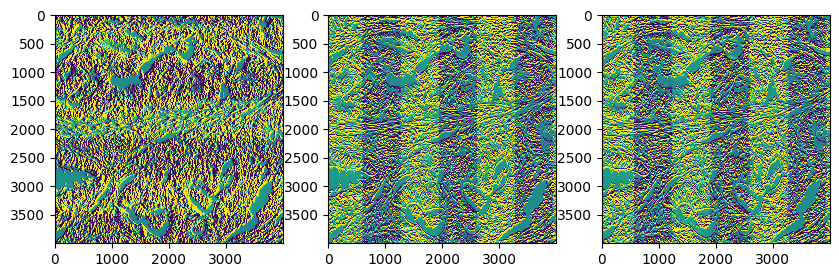

In [10]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10, 5))
ax0.imshow(sparse_matrix_x_crop, vmin=-1, vmax=1)
ax1.imshow(sparse_matrix_y_crop_new, vmin=-1, vmax=1)
ax2.imshow(sparse_matrix_y_crop_warp, vmin=-1, vmax=1)
plt.show()

In [11]:
plt.imsave(os.path.join(result_dir, "test_shift_x_green.png"), sparse_matrix_x_crop)
plt.imsave(os.path.join(result_dir, "test_shift_y.png"), sparse_matrix_y_crop)
if axis == "x":
    plt.imsave(os.path.join(result_dir, "test_shift_x_warp.png"), sparse_matrix_y_crop_warp)
else:
    plt.imsave(os.path.join(result_dir, "test_shift_y_warp.png"), sparse_matrix_y_crop_warp)

In [12]:
if axis == "x":
    np.save(os.path.join(result_dir, "test_shift_x.npy"), sparse_matrix_y_crop_warp / sparse_matrix_y_crop_warp.max())
else:
    np.save(os.path.join(result_dir, "test_shift_y_warp.npy"), sparse_matrix_y_crop_warp / sparse_matrix_y_crop_warp.max())
# np.save(os.path.join(result_dir, "test_shift_x.npy"), sparse_matrix_x_crop_new / sparse_matrix_x_crop_new.max())
# np.save(os.path.join(result_dir, "test_shift_y.npy"), sparse_matrix_y_crop / sparse_matrix_y_crop.max())

In [13]:
# norm_u_v = np.sqrt(u**2 + v**2)
# plt.imsave(os.path.join(result_dir, "test_shift_norm_u_v.png"), norm_u_v)